# EDA: Diabetes 130-US Hospitals for Years 1999-2008

Analisis exploratorio de datos (EDA) del dataset de reingresos hospitalarios de pacientes diabeticos,
obtenido del UCI Machine Learning Repository (id=296).

Contiene 101,766 encuentros hospitalarios y 47 variables (demograficas, clinicas y de medicacion),
mas la variable objetivo `readmitted` (si el paciente fue readmitido: `NO`, `>30` dias, `<30` dias).

https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

## 1. Carga de librerias y del dataset

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

In [2]:
# En caso de que no se tenga, se debe hacer pip install de la librería ucimlrepo y del scikitlearn

In [3]:
# !pip install ucimlrepo 
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# dataframe combinado features + target, usado en todo el EDA
df = pd.concat([X, y], axis=1)

# metadata y descripcion de variables
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata)
diabetes_130_us_hospitals_for_years_1999_2008.variables

{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

,name,role,type,demographic,description,units,missing_values
0,encounter_id,ID,,NaN,Unique identifier of an encounter,None,no
1,patient_nbr,ID,,NaN,Unique identifier of a patient,None,no
2,race,Feature,Categorical,Race,"Values: Caucasian, Asian, African American, Hi...",None,yes
3,gender,Feature,Categorical,Gender,"Values: male, female, and unknown/invalid",None,no
4,age,Feature,Categorical,Age,"Grouped in 10-year intervals: [0, 10), [10, 20...",None,no
5,weight,Feature,Categorical,NaN,Weight in pounds.,None,yes
6,admission_type_id,Feature,Categorical,NaN,Integer identifier corresponding to 9 distinct...,None,no
7,discharge_disposition_id,Feature,Categorical,NaN,Integer identifier corresponding to 29 distinc...,None,no
8,admission_source_id,Feature,Categorical,NaN,Integer identifier corresponding to 21 distinc...,None,no
9,time_in_hospital,Feature,Integer,NaN,Integer number of days between admission and d...,None,no


> **Codigo: .** Descargamos el dataset directamente del repositorio UCI con `fetch_ucirepo(id=296)`, separamos las variables predictoras (`X`) del target (`y`), las unimos en un único DataFrame `df` e imprimimos la metadata junto con el diccionario de variables.
>
> **Por qué.** Traer los datos desde la fuente original (en vez de un CSV descargado a mano) hace el análisis reproducible: cualquiera que ejecute el notebook obtiene exactamente los mismos datos. Y antes de tocar una sola columna conviene leer el diccionario de variables, porque nombres como `diag_1` o `A1Cresult` no se entienden solos.
>
> **Qué descubrimos.**
> - El dataset tiene **101,766 instancias y 47 features**, con `readmitted` como target. La **unidad de análisis es el encuentro hospitalario, no el paciente**: un mismo paciente puede aparecer varias veces.
> - `encounter_id` y `patient_nbr` están declaradas como `index_col`, por lo que `ucimlrepo` **no las incluye en `X`**. Esto nos limita más adelante (no podremos agrupar por paciente).
> - La metadata avisa `has_missing_values: yes`, y el diccionario marca con faltantes exactamente 7 columnas: `race`, `weight`, `payer_code`, `medical_specialty`, `diag_1`, `diag_2` y `diag_3`. Guardemos este dato: más adelante veremos que **la realidad no coincide con el diccionario**.
> - `sensitive_data: yes` (edad, género y raza). Es un dataset clínico con atributos protegidos, así que cualquier conclusión por subgrupo hay que leerla con cuidado por posible sesgo.
> - El criterio de inclusión del estudio original: solo hospitalizaciones de **1 a 14 días** en las que se hicieron pruebas de laboratorio y se administraron medicamentos. Por eso ninguna estancia llegará a 30 días, por ejemplo.

## 2. Vista general del dataset

In [5]:
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 101,766 | Columnas: 48


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


> **Codigo: .** Consultamos las dimensiones del DataFrame y mostramos las primeras 5 filas con `head()`.
>
> **Por qué.** Es el chequeo más básico después de cargar datos: confirmar que la unión `X + y` no duplicó ni perdió filas, y ver el aspecto real de los datos en vez de imaginarlo desde el diccionario.
>
> **Qué descubrimos.**
> - **101,766 filas x 48 columnas** = las 47 features + el target. La concatenación funcionó bien (el número de filas coincide con la metadata).
> - Ya a simple vista aparecen `NaN` en `weight`, `payer_code`, `medical_specialty`, `max_glu_serum` y `A1Cresult`: los faltantes no son un caso raro, saltan en las primeras 5 filas.
> - `age` **no es numérica**: viene como rango de texto (`[0-10)`, `[10-20)`, ...). Es una variable ordinal disfrazada de categórica y habrá que codificarla.
> - Los diagnósticos (`diag_1`, `diag_2`, `diag_3`) son **códigos ICD-9 guardados como texto** (`250.83`, `276`, `V27`). No son números aunque lo parezcan: `250.83` y `250.01` son ambos diabetes, mientras que `276` es un trastorno electrolítico.
> - Las 23 columnas de medicamentos usan el esquema `No / Steady / Up / Down` (no se recetó / dosis estable / se subió / se bajó).

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      99493 non-null   str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   weight                    3197 non-null    str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   payer_code                61510 non-null   str  
 9   medical_specialty         51817 non-null   str  
 10  num_lab_procedures        101766 non-null  int64
 11  num_procedures            101766 non-null  int64
 12  num_medications           101766 non-null  int64
 13  number_outpatient         101766 non-null  int64
 14  number_emergency          10176

> **Codigo: .** Llamamos a `df.info()` para ver el tipo de dato y el conteo de valores no nulos de cada una de las 48 columnas.
>
> **Por qué.** Es la forma más rápida de detectar dos problemas a la vez: tipos mal inferidos por pandas (números leídos como texto o viceversa) y la magnitud de los valores faltantes columna por columna. También nos dice si el dataset cabe cómodo en memoria.
>
> **Qué descubrimos.**
> - **11 columnas `int64` y 37 de tipo texto**, con un consumo de solo **37.3 MB**: podemos trabajar en memoria sin problema.
> - Los conteos de no nulos cuantifican los faltantes: `weight` solo tiene **3,197 de 101,766** valores, `max_glu_serum` **5,346**, `A1Cresult` **17,018**, `medical_specialty` **51,817**, `payer_code` **61,510** y `race` **99,493**.
> - **Trampa importante:** `admission_type_id`, `discharge_disposition_id` y `admission_source_id` son `int64`, pero **son categorías codificadas con números**, no cantidades. Que el "tipo de admisión promedio" sea 2.02 no significa nada. Pandas no puede saberlo, nosotros sí, y hay que tenerlo presente en todo lo que venga después.
> - Ninguna columna quedó como texto conteniendo números, así que no hay conversiones de tipo urgentes que hacer.

In [7]:
# tipos de dato y numero de valores unicos por columna
resumen = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unicos": df.nunique(),
    "n_nulos": df.isnull().sum(),
})
resumen["%_nulos"] = (resumen["n_nulos"] / len(df) * 100).round(1)
resumen.sort_values("%_nulos", ascending=False)

,dtype,n_unicos,n_nulos,%_nulos
weight,str,9,98569,96.9
max_glu_serum,str,3,96420,94.7
A1Cresult,str,3,84748,83.3
medical_specialty,str,72,49949,49.1
payer_code,str,17,40256,39.6
race,str,5,2273,2.2
diag_3,str,789,1423,1.4
diag_2,str,748,358,0.4
time_in_hospital,int64,14,0,0.0
admission_source_id,int64,17,0,0.0


> **Codigo: .** Construimos una tabla `resumen` que reúne, para cada columna, tres cosas: su tipo de dato, su número de valores únicos (`n_unicos`) y su cantidad y porcentaje de nulos. La ordenamos por porcentaje de nulos.
>
> **Por qué.** `info()` da la información, pero dispersa y sin porcentajes. Aquí la dejamos en un DataFrame **ordenable y reutilizable** (lo usaremos en la sección 3), con las tres métricas que realmente deciden el preprocesamiento de una columna: *tipo*, *cardinalidad* y *faltantes*.
>
> **Qué descubrimos.**
> - **Faltantes, ordenados:** `weight` **96.9%**, `max_glu_serum` **94.7%**, `A1Cresult` **83.3%**, `medical_specialty` **49.1%**, `payer_code` **39.6%**, `race` **2.2%**, `diag_3` **1.4%**, `diag_2` **0.4%** y `diag_1` solo 21 filas. Las otras 39 columnas están completas.
> - **Aquí aparece la contradicción que anticipamos:** el diccionario de UCI decía que `max_glu_serum` y `A1Cresult` **no** tenían faltantes, y son la segunda y tercera columna más vacías. La pista está en `n_unicos = 3` para ambas: en el CSV original estas columnas tienen 4 categorías, y la cuarta es literalmente `"None"` (= la prueba no se realizó), que `ucimlrepo` convirtió en `NaN`. **Ese `NaN` no es un dato perdido, es información:** significa "no se midió". Lo retomamos en la sección 3.
> - **Columnas constantes:** `examide` y `citoglipton` tienen **un único valor** (`n_unicos = 1`). Tienen varianza cero, no pueden aportar nada a ningún modelo y se deben eliminar.
> - **Columnas casi constantes:** `acetohexamide`, `tolbutamide`, `troglitazone`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone` y `metformin-pioglitazone` tienen solo 2 valores únicos. Habría que confirmarlo con `value_counts()`, pero es casi seguro que en la práctica también son constantes.
> - **Cardinalidad alta:** `diag_1`, `diag_2` y `diag_3` tienen **716, 748 y 789 categorías**. Hacerles one-hot encoding generaría más de 2,200 columnas. Lo correcto es **agruparlas por capítulo ICD-9** (circulatorio, respiratorio, diabetes, etc.) y reducirlas a unos 9 grupos. `medical_specialty`, con 72 categorías, tiene el mismo problema en menor escala.
> - `time_in_hospital` tiene exactamente 14 valores únicos: coherente con el rango de 1 a 14 días del criterio de inclusión.

In [8]:
# duplicados a nivel de fila y de paciente (un mismo paciente puede tener varios encuentros)
print("Filas duplicadas:", df.duplicated().sum())
print("Pacientes unicos:", X["patient_nbr"].nunique() if "patient_nbr" in X.columns else "columna no incluida por ucimlrepo")

Filas duplicadas: 0
Pacientes unicos: columna no incluida por ucimlrepo


> **Codigo: .** Contamos las filas exactamente duplicadas e intentamos contar los pacientes únicos.
>
> **Por qué.** Los duplicados exactos inflan artificialmente el dataset y sesgan cualquier estadística. Pero en datos hospitalarios hay un problema más sutil y más grave: si un mismo paciente aparece en varias filas, **las filas no son independientes**. Si ese paciente cae a la vez en entrenamiento y en test, el modelo se evalúa con información que ya vio y su rendimiento sale inflado (fuga de datos, o *data leakage*).
>
> **Qué descubrimos.**
> - **0 filas duplicadas.** No hay que limpiar nada por ese lado.
> - **No pudimos contar los pacientes únicos:** `patient_nbr` no está en `X` porque `ucimlrepo` la trata como columna identificadora (lo vimos en `index_col`). El propio código lo maneja con un condicional y avisa `columna no incluida por ucimlrepo`.
> - Esto **no es un detalle menor**: sabemos por la metadata que la unidad es el encuentro y no el paciente, así que con seguridad hay pacientes repetidos y no podemos medir cuántos. Y es una pregunta que no podemos dejar abierta, porque de ella depende que las filas sean o no independientes. Se resuelve recuperando los identificadores desde `diabetes_130_us_hospitals_for_years_1999_2008.data.ids`, que es donde `ucimlrepo` los guarda aparte: **es exactamente lo que hace la celda siguiente**.

In [9]:
# recuperamos los identificadores que ucimlrepo separa en .data.ids
ids = diabetes_130_us_hospitals_for_years_1999_2008.data.ids
df_id = pd.concat([ids, df], axis=1)

n_enc = len(df_id)
n_pac = df_id["patient_nbr"].nunique()
enc_por_pac = df_id["patient_nbr"].value_counts()
repetidos = enc_por_pac[enc_por_pac > 1]

print(f"Encuentros: {n_enc:,} | Pacientes unicos: {n_pac:,} | Media de encuentros por paciente: {n_enc / n_pac:.2f}")
print(f"Maximo de encuentros de un solo paciente: {enc_por_pac.max()}")
print(f"Pacientes con mas de un encuentro: {len(repetidos):,} ({len(repetidos) / n_pac * 100:.1f}% de los pacientes)")
print(f"Filas que pertenecen a pacientes repetidos: {repetidos.sum():,} ({repetidos.sum() / n_enc * 100:.1f}% de las filas)")

# cuanto se filtraria con un split aleatorio por fila, sin agrupar por paciente
rng = np.random.default_rng(0)
orden = rng.permutation(n_enc)
corte = int(n_enc * 0.8)
pac_train = set(df_id["patient_nbr"].iloc[orden[:corte]])
pac_test = df_id["patient_nbr"].iloc[orden[corte:]]
print(f"\nSplit aleatorio 80/20 por fila -> filas de test con un paciente ya visto en train: "
      f"{pac_test.isin(pac_train).sum():,} de {len(pac_test):,} ({pac_test.isin(pac_train).mean() * 100:.1f}%)")

# la misma estadistica por encuentro y quedandose con el primer encuentro de cada paciente
primero = df_id.sort_values("encounter_id").groupby("patient_nbr", as_index=False).first()
pd.DataFrame({
    "por encuentro": [n_enc, (df_id["readmitted"] == "<30").mean() * 100, df_id["number_inpatient"].mean()],
    "por paciente": [len(primero), (primero["readmitted"] == "<30").mean() * 100, primero["number_inpatient"].mean()],
}, index=["n filas", "% readmision <30", "media de number_inpatient"]).round(2)

Encuentros: 101,766 | Pacientes unicos: 71,518 | Media de encuentros por paciente: 1.42
Maximo de encuentros de un solo paciente: 40
Pacientes con mas de un encuentro: 16,773 (23.5% de los pacientes)
Filas que pertenecen a pacientes repetidos: 47,021 (46.2% de las filas)

Split aleatorio 80/20 por fila -> filas de test con un paciente ya visto en train: 8,441 de 20,354 (41.5%)


,por encuentro,por paciente
n filas,101766.00,71518.00
% readmision <30,11.16,8.80
media de number_inpatient,0.64,0.18


> **Codigo: .** Recuperamos `encounter_id` y `patient_nbr` desde `.data.ids` (donde `ucimlrepo` los separa por ser identificadores), contamos cuántos pacientes distintos hay realmente, medimos cuánta información se filtraría con un `train_test_split` aleatorio corriente y comparamos tres estadísticas clave vistas por encuentro y por paciente.
>
> **Por qué.** La celda anterior nos dejó una pregunta sin responder, y no es una curiosidad: **casi toda la validez estadística del análisis depende de si las filas son independientes o no**. Sin esta comprobación estaríamos trabajando a ciegas sobre el supuesto más importante.
>
> **Qué descubrimos.**
> - **101,766 encuentros pertenecen a solo 71,518 pacientes** (1.42 hospitalizaciones por persona de media), y hay un paciente que aparece **40 veces**.
> - **16,773 pacientes (el 23.5%) tienen más de un encuentro, y esas filas son el 46.2% del dataset.** Es decir: casi la mitad de las filas **no son observaciones independientes**. El `0 filas duplicadas` de la celda anterior era una falsa tranquilidad: no hay filas idénticas, pero sí filas relacionadas entre sí.
> - **Un `train_test_split` aleatorio corriente sería un desastre:** el 41.5% de las filas de test corresponden a un paciente que el modelo ya vio en entrenamiento. El modelo memorizaría personas en lugar de aprender el fenómeno, y la métrica de evaluación saldría inflada.
> - **La duplicación desplaza las estadísticas.** Al quedarnos con el primer encuentro de cada paciente, la tasa de readmisión temprana baja del **11.16% al 8.80%**, y la media de `number_inpatient` cae de **0.64 a 0.18**, a menos de un tercio. Tiene una explicación estructural: en el segundo y tercer encuentro de un paciente, sus hospitalizaciones previas **son otras filas de este mismo dataset**.
>
> **Qué decidimos y por qué.** Conservamos **todos los encuentros** y asumimos el cuidado extra que eso exige, en lugar de reducir a un encuentro por paciente. La razón es que **el encuentro es la unidad correcta para la pregunta real**: Medicare penaliza por ingreso, y un modelo en producción puntuaría cada admisión que entra al hospital, incluida la tercera de un paciente crónico. Quedarnos con el primer encuentro responderría una pregunta más estrecha y descartaría el 30% de los datos junto con toda la información de trayectoria del paciente.
>
> Los cuidados que esa decisión obliga a tomar:
> 1. **Nunca un split aleatorio por fila.** El split debe agrupar por paciente, con `patient_nbr` como clave de grupo, y estratificar por el target (que está desbalanceado). En la etapa de modelado: `StratifiedGroupKFold(n_splits=5)` con `groups=df_id["patient_nbr"]`, o `GroupShuffleSplit` para un único holdout (requiere `scikit-learn`).
> 2. **`patient_nbr` y `encounter_id` nunca son features**, solo clave de agrupación y de orden. Un identificador no tiene significado: dárselo a un modelo solo le permite memorizar.
> 3. **Al reportar cifras descriptivas, decir siempre respecto a qué se calculan.** "El 11.2% de los *encuentros* termina en readmisión temprana" es correcto; "el 11.2% de los *pacientes*" no lo es.
> 4. **Interpretar `number_inpatient` con matiz.** No es fuga de datos (cuenta visitas del año anterior al ingreso, así que es conocible en el momento de predecir), pero parte de su fuerza aparente viene de la estructura de pacientes repetidos.
> 5. **`encounter_id` es el único indicio de orden temporal** (el dataset no trae fechas). Sirve para ordenar los encuentros de un paciente, pero conviene declararlo como supuesto.

## 3. Valores nulos

Varias columnas usan `NaN` (originalmente `?` en el dataset crudo) para representar datos faltantes.
`weight`, `max_glu_serum` y `A1Cresult` estan casi vacias y normalmente se descartan o se tratan como
"no medido" en vez de imputarse.

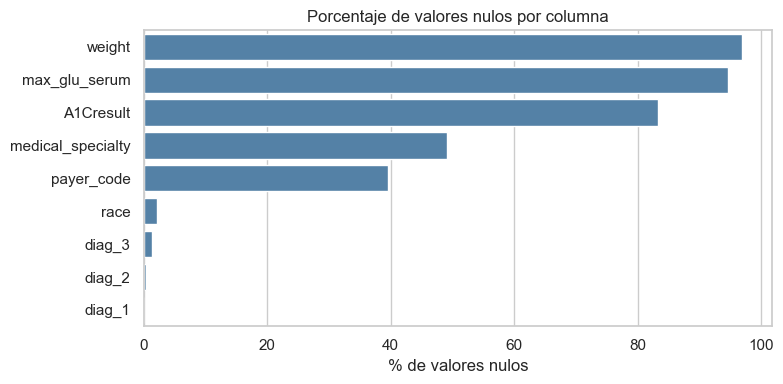

In [10]:
nulos = resumen[resumen["n_nulos"] > 0].sort_values("%_nulos", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=nulos["%_nulos"], y=nulos.index, ax=ax, color="steelblue")
ax.set_xlabel("% de valores nulos")
ax.set_ylabel("")
ax.set_title("Porcentaje de valores nulos por columna")
plt.tight_layout()
plt.show()

> **Codigo: .** Filtramos de `resumen` solo las columnas con al menos un nulo y graficamos su porcentaje en un gráfico de barras horizontales ordenado.
>
> **Por qué.** La tabla anterior tiene 48 filas y hay que leerla con atención; el gráfico responde de un vistazo a la pregunta "qué tan grave es el problema de faltantes y en cuántas columnas". Filtramos las columnas completas porque 39 barras en cero solo serían ruido visual.
>
> **Qué descubrimos.** Los faltantes **no son un problema homogéneo**: se ven tres bloques muy distintos, y cada uno pide una decisión diferente.
>
> 1. **Casi vacías (más del 80%):** `weight` (96.9%), `max_glu_serum` (94.7%) y `A1Cresult` (83.3%).
> 2. **Parcialmente vacías (40-50%):** `medical_specialty` (49.1%) y `payer_code` (39.6%).
> 3. **Prácticamente completas (menos del 2.5%):** `race`, `diag_3`, `diag_2` y `diag_1` (esta última con una barra invisible: 21 filas).
>
> Y la decisión para cada bloque:
> - `weight` se **descarta**: con 3,197 valores de 101,766 no hay forma de imputarla sin inventar datos.
> - `max_glu_serum` y `A1Cresult` **no se imputan ni se descartan**. Como acabamos de ver, su `NaN` significa "la prueba no se realizó", y eso **es un dato en sí mismo**. De hecho, el paper original de este dataset (*"Impact of HbA1c Measurement on Hospital Readmission Rates"*) estudia exactamente eso: si medir la HbA1c cambia la tasa de reingreso. Convertirlas a una categoría explícita `"No medido"` conserva esa señal; imputarlas la destruiría.
> - `medical_specialty` y `payer_code`: mismo tratamiento, categoría `"Desconocido"`. Que no se haya registrado la especialidad o la aseguradora puede correlacionar con el tipo de ingreso.
> - `race`, `diag_1`, `diag_2` y `diag_3`: son tan pocos casos que se pueden imputar con la moda o eliminar esas filas sin impacto apreciable.
>
> **Lección general del EDA:** antes de imputar un `NaN` hay que preguntarse *por qué* falta. Si falta porque nadie lo midió, la ausencia es información y hay que codificarla, no rellenarla.

## 4. Variable objetivo: `readmitted`

Variable categorica con 3 clases: el paciente no fue readmitido (`NO`), fue readmitido despues de 30 dias
(`>30`) o fue readmitido antes de 30 dias (`<30`). Esta ultima suele ser la clase de mayor interes clinico
y esta desbalanceada frente a las otras dos.

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: count, dtype: float64


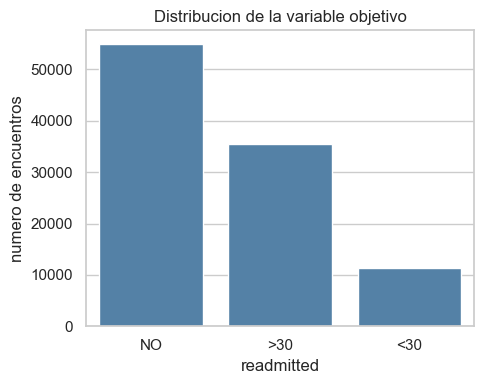

In [11]:
conteo = df["readmitted"].value_counts()
print(conteo)
print((conteo / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=conteo.index, y=conteo.values, ax=ax, color="steelblue", order=["NO", ">30", "<30"])
ax.set_xlabel("readmitted")
ax.set_ylabel("numero de encuentros")
ax.set_title("Distribucion de la variable objetivo")
plt.tight_layout()
plt.show()

> **Codigo: .** Contamos los encuentros de cada una de las 3 clases de `readmitted`, calculamos sus porcentajes y las graficamos en el orden lógico `NO`, `>30`, `<30`.
>
> **Por qué.** El target es la variable más importante del análisis: su distribución determina la métrica de evaluación y la estrategia de modelado. Y hay que mirarla **antes** de explorar los predictores, porque condiciona cómo se interpreta todo lo demás.
>
> **Qué descubrimos.**
> - **`NO`: 54,864 encuentros (53.9%)**, **`>30`: 35,545 (34.9%)** y **`<30`: 11,357 (11.2%)**.
> - Casi la mitad de los encuentros (**46.1%**) termina en un reingreso en algún momento. Es una cifra alta, coherente con que hablamos de pacientes crónicos.
> - **La clase que importa es la minoritaria.** La readmisión temprana (`<30`) es la de mayor relevancia clínica y económica (en EE.UU. Medicare penaliza a los hospitales por reingresos antes de 30 días), y es **solo 1 de cada 9 encuentros**: un desbalance de aproximadamente **8 a 1**.
> - **Consecuencia práctica muy concreta:** un modelo que prediga "no hay readmisión temprana" para absolutamente todos los pacientes acertaría el **88.8%** de las veces. Eso significa que **el *accuracy* es una métrica inútil en este problema**: hay que evaluar con *recall*, *precision*, F1 o PR-AUC sobre la clase `<30`, y considerar técnicas de balanceo (`class_weight`, submuestreo o SMOTE) al entrenar.
> - Por eso en la sección 8 agrupamos el target en binario (`<30` frente al resto): es la pregunta que realmente queremos responder.

## 5. Variables numericas

In [12]:
num_cols = X.select_dtypes(include="number").columns.tolist()
print(num_cols)
df[num_cols].describe().T

['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


> **Codigo: .** Seleccionamos automáticamente las columnas numéricas con `select_dtypes(include="number")` y calculamos su estadística descriptiva, transpuesta (`.T`) para leerla cómodamente.
>
> **Por qué.** `describe()` resume en una tabla las escalas, los rangos y la forma de cada distribución. Comparar **media contra mediana** revela asimetría, y comparar **percentil 75 contra máximo** revela colas largas y posibles valores extremos.
>
> **Qué descubrimos.**
> - `select_dtypes` devolvió **11 columnas, pero 3 son falsos positivos**: `admission_type_id`, `discharge_disposition_id` y `admission_source_id` son los códigos categóricos que ya habíamos identificado. Sus medias (2.02, 3.72, 5.75) **no tienen ninguna interpretación**. Es un buen recordatorio de que la selección automática por tipo de dato siempre necesita revisión manual.
> - **`time_in_hospital`:** media 4.4 días, mediana 4, mínimo 1 y máximo 14. Distribución razonablemente centrada y acotada por diseño del estudio.
> - **`num_lab_procedures`:** la variable de mayor rango, de 1 a 132, con media 43 y mediana 44. Media y mediana casi iguales, así que es bastante simétrica.
> - **`num_medications`:** media 16, mediana 15, máximo 81. Ligeramente sesgada a la derecha.
> - **`number_outpatient`, `number_emergency` y `number_inpatient`:** aquí está el hallazgo más fuerte. **Su mediana y también su percentil 75 son 0**, pero sus máximos son **42, 76 y 21**. Es decir: la gran mayoría de pacientes no tuvo visitas previas, y unos pocos tuvieron muchísimas. Son distribuciones **extremadamente asimétricas** que necesitarán transformación (`log1p`) o binarización (`tuvo_visitas_previas`, sí/no) antes de modelar.
> - **`number_diagnoses`:** media 7.4, mediana 8, percentil 75 en 9 y máximo 16. Muy concentrada en valores altos: estos pacientes tienen muchas comorbilidades. Ese percentil 75 exactamente en 9, con un máximo de 16, es una señal sospechosa que la celda siguiente nos permitirá confirmar.
> - **Las escalas son muy dispares** (de 0-6 en `num_procedures` a 1-132 en `num_lab_procedures`). Si luego usamos un modelo sensible a distancias (KNN, SVM) o con regularización, hay que **estandarizar**.

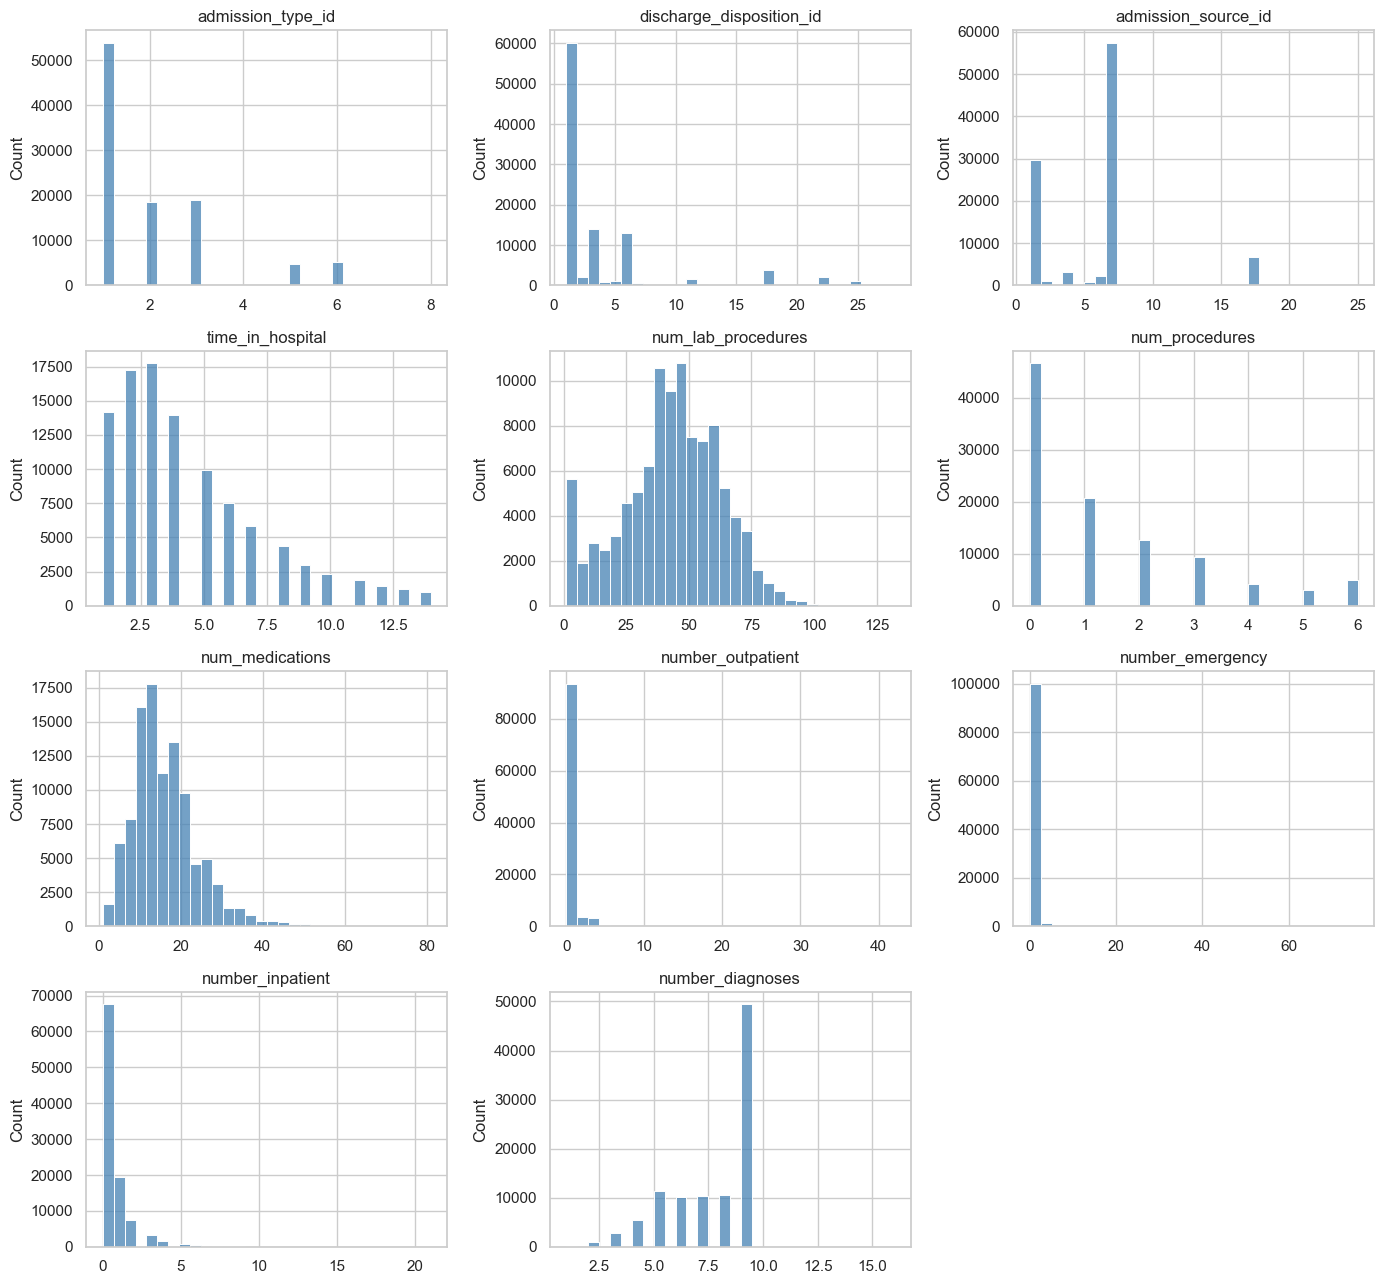

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(14, 13))
for col, ax in zip(num_cols, axes.ravel()):
    sns.histplot(df[col], bins=30, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

> **Codigo: .** Graficamos un histograma de cada una de las 11 variables numéricas en una grilla de 4x3, para ver su forma.
>
> **Por qué.** `describe()` da números; el histograma da la **forma** de la distribución, que los números esconden. Dos variables pueden tener la misma media y la misma mediana y distribuciones completamente distintas (una campana, dos picos, o todo acumulado en un solo valor).
>
> **Qué descubrimos.**
> - **Los tres `*_id` no son números.** Sus histogramas son barras aisladas y separadas, no distribuciones continuas: la confirmación visual de que son códigos categóricos. `discharge_disposition_id` está dominado por el código 1 (unos 60,000 casos, alta a domicilio) y `admission_source_id` se concentra en el 7 (unos 57,000, ingreso por urgencias) y el 1 (unos 29,000, referencia médica). Traducir esos códigos a etiquetas legibles sería un buen paso siguiente.
> - **`time_in_hospital`:** claramente **sesgada a la derecha**, con la moda en 2-3 días y una cola que decae hasta los 14. La mayoría de las estancias son cortas.
> - **`num_lab_procedures`:** aproximadamente una campana centrada en 44, pero **con una anomalía**: un pico aislado en el extremo izquierdo (**5,641 encuentros** con 5 pruebas o menos, y la moda de la variable es **1**, con 3,208 encuentros). Es llamativo, porque el criterio de inclusión del dataset exigía que se hubieran realizado pruebas de laboratorio. **Vale la pena investigar ese grupo**: podría ser un error de registro o un tipo de ingreso particular.
> - **`num_medications`:** campana sesgada a la derecha, moda entre 13 y 15 medicamentos, con cola larga hasta 81.
> - **`num_procedures`:** casi la mitad de los encuentros (unos 47,000) tiene **0 procedimientos**.
> - **`number_outpatient` y `number_emergency`:** una sola barra gigantesca en 0 y el resto invisible. Es la **confirmación visual de la asimetría extrema** que ya sospechábamos por el `describe()`. Un histograma normal no sirve para verlas; habría que usar escala logarítmica en el eje Y.
> - **`number_inpatient`:** decae de forma escalonada y muy marcada: **unos 67,000 encuentros en 0** (el 66% del total), unos 19,000 en 1, unos 7,500 en 2, y a partir de 5 hospitalizaciones previas queda apenas un 2% de los casos. Es asimétrica como las otras dos del historial, pero **con bastante más estructura visible**: aquí sí se distinguen escalones, y eso es justamente lo que la hará útil en la sección 8.
> - **`number_diagnoses`: el hallazgo más llamativo de esta celda.** No es una distribución natural en absoluto: hay una **meseta plana entre 5 y 8** diagnósticos (unos 10,000 encuentros en cada valor) y de golpe un **pico enorme en exactamente 9, con 49,474 encuentros, casi la mitad del dataset (48.6%)**. Y por encima de 9 la variable **se corta en seco**: solo **115 registros de 101,766** (el 0.11%) tienen más de 9 diagnósticos, aunque el máximo llegue a 16.
>   - Eso no es un patrón clínico, es un **artefacto administrativo**: el sistema de facturación permitía registrar hasta 9 códigos de diagnóstico, así que "9" en realidad significa "9 o más". La variable está **truncada (censurada) por arriba**.
>   - **Consecuencia práctica:** tratarla como un conteo continuo es engañoso, porque la diferencia entre 8 y 9 no es comparable a la que hay entre 5 y 6. Es más honesto convertirla en categórica o agrupada (por ejemplo `1-5`, `6-8`, `9+`), y desconfiar de los 115 valores por encima de 9, que probablemente vengan de un sistema de registro distinto.
>   - Es un buen ejemplo de por qué el EDA visual importa: en el `describe()` esta variable parecía perfectamente normal (media 7.4, mediana 8), y solo el histograma revela que **casi la mitad de los datos está apilada en un único valor por un límite del software, no de la medicina**.

## 6. Variables categoricas clave

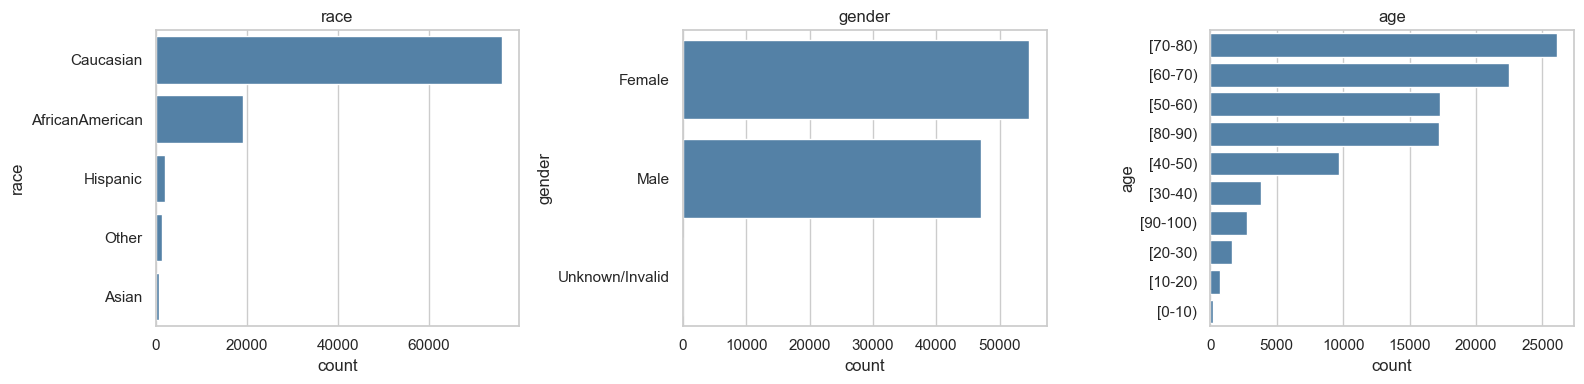

In [14]:
cat_demo = ["race", "gender", "age"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for col, ax in zip(cat_demo, axes):
    orden = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=orden, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

> **Codigo: .** Graficamos la frecuencia de las tres variables demográficas (`race`, `gender`, `age`) con barras horizontales, ordenadas de mayor a menor.
>
> **Por qué.** Necesitamos saber **a quién representan estos datos** antes de generalizar cualquier conclusión. Además, este dataset está marcado como `sensitive_data`, así que identificar los grupos poco representados es una cuestión de rigor: sobre un grupo con pocos casos no se pueden sacar conclusiones fiables, y un modelo entrenado así tenderá a funcionar peor precisamente en esos grupos.
>
> **Qué descubrimos.**
> - **`race`:** fuertemente dominada por `Caucasian` (unos 75,000) y `AfricanAmerican` (unos 19,000). `Hispanic`, `Other` y `Asian` juntas no llegan al 5% del total. Cualquier análisis desagregado por raza será sólido para los dos primeros grupos y poco fiable para los demás. Recordemos además su 2.2% de nulos.
> - **`gender`:** reparto bastante equilibrado, `Female` (unos 54,000) algo por encima de `Male` (unos 47,000). Pero aparece una tercera categoría, **`Unknown/Invalid`, con una barra prácticamente inexistente**: son los 3 valores únicos que ya habíamos visto en `resumen`. Es un puñado de registros inválidos que conviene eliminar o convertir a nulos.
> - **`age`:** el hallazgo más relevante de esta celda. La población es **mayoritariamente de edad avanzada**: el pico está en **`[70-80)` (unos 26,000)**, seguido de `[60-70)` (unos 22,000), y luego `[50-60)` y `[80-90)` (unos 17,000 cada uno). Los tramos por debajo de 30 años son casi inexistentes. Esto es coherente con la diabetes tipo 2, pero significa que **las conclusiones de este análisis aplican a población adulta mayor**, no a pacientes jóvenes.
> - Como ya notamos, `age` es **ordinal** (los rangos tienen un orden natural). Para modelar conviene mapearla a un valor numérico (el punto medio: 5, 15, 25...) o codificarla como ordinal, **nunca** con one-hot, que tiraría a la basura esa información de orden.

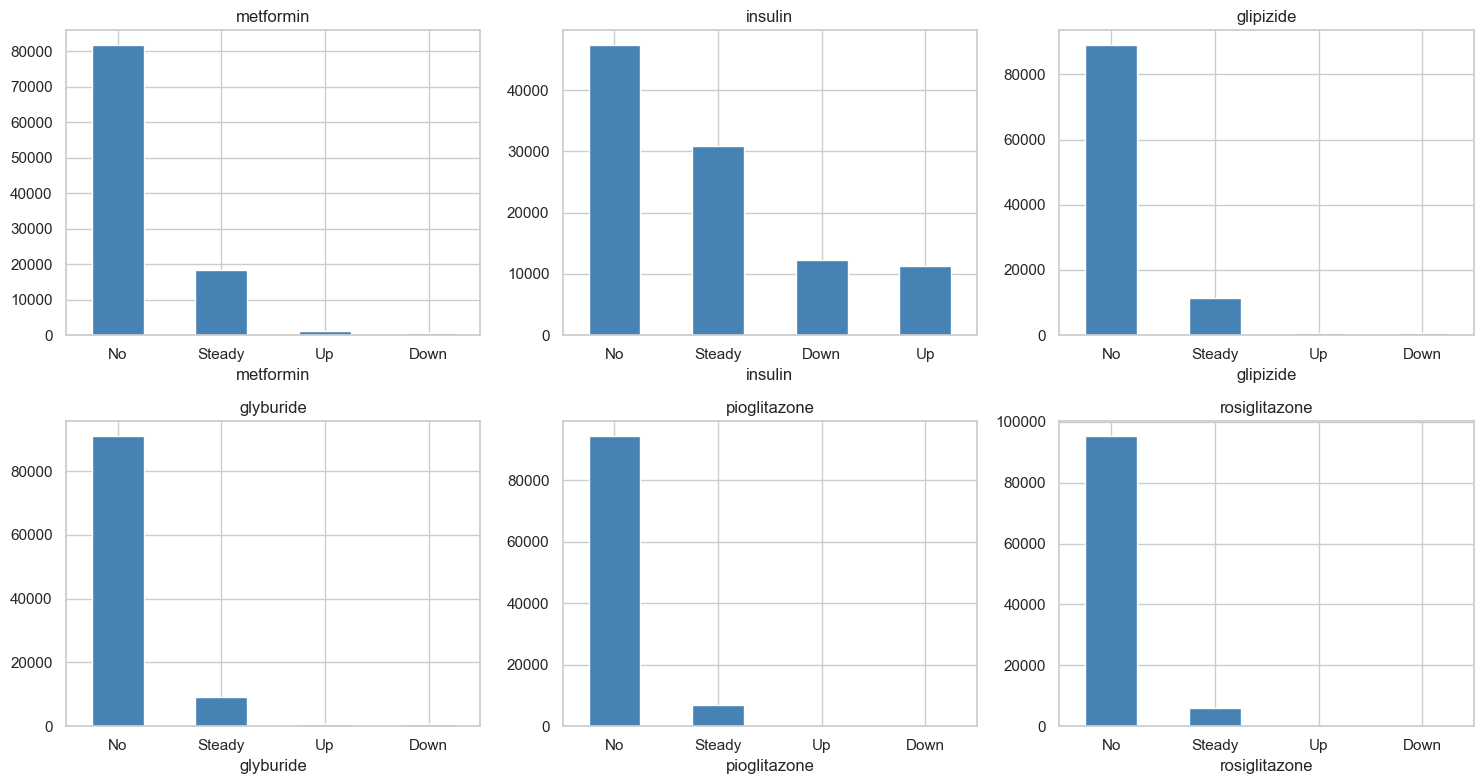

In [15]:
# variables de medicacion: para cada droga, que tan frecuente es cada categoria (No / Steady / Up / Down)
drogas = [
    "metformin", "insulin", "glipizide", "glyburide", "pioglitazone", "rosiglitazone",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(drogas, axes.ravel()):
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

> **Codigo: .** Para 6 de las 23 columnas de medicamentos, graficamos cuán frecuente es cada una de sus 4 categorías: `No` (no se recetó), `Steady` (dosis sin cambios), `Up` (se aumentó) y `Down` (se redujo).
>
> **Por qué.** Ya sospechábamos por la cardinalidad de `resumen` que muchas de estas columnas aportan poco. Aquí lo verificamos: una variable en la que el 95% de los casos cae en la misma categoría tiene muy poca **varianza**, y sin varianza no hay capacidad predictiva. El objetivo es decidir cuáles conservar.
>
> **Qué descubrimos.**
> - **`insulin` es la excepción, y la variable de medicación más informativa del dataset.** Es la única con un reparto real entre las cuatro categorías: `No` unos 47,000, `Steady` unos 31,000, `Down` unos 12,000 y `Up` unos 11,000. Es decir, **más de la mitad de los encuentros la usan** y en cerca del 23% **se ajustó la dosis** durante la estancia. Ese ajuste es una señal clínica valiosa: apunta a descontrol glucémico.
> - **`metformin`** tiene algo de variabilidad (unos 81,000 `No` frente a unos 18,000 `Steady`), pero casi ningún ajuste de dosis.
> - **`glipizide`, `glyburide`, `pioglitazone` y `rosiglitazone`** están entre el 88% y el 95% en `No`, con `Up` y `Down` prácticamente en cero. Son **casi constantes**.
> - **Conclusión práctica:** aplicar one-hot encoding a las 23 columnas de medicamentos generaría decenas de columnas casi vacías que solo agregan ruido y dimensionalidad. Es mucho mejor **quedarse con `insulin` (y quizá `metformin`) y construir variables agregadas**, por ejemplo `n_farmacos_activos` (cuántos medicamentos distintos recibe el paciente) o `hubo_ajuste_de_dosis` (si algún fármaco aparece como `Up` o `Down`). Esto se llama *feature engineering*: crear variables con más señal a partir de las originales.
>
> **Nota cosmética:** en cada subgráfico el nombre del fármaco aparece dos veces (como título y como etiqueta del eje X), porque el `plot(kind="bar")` de pandas escribe el nombre del índice automáticamente. Se limpia agregando `ax.set_xlabel("")` dentro del bucle.

In [16]:
print("change:")
print(df["change"].value_counts(normalize=True).round(3), "\n")
print("diabetesMed:")
print(df["diabetesMed"].value_counts(normalize=True).round(3))

change:
change
No    0.538
Ch    0.462
Name: proportion, dtype: float64 

diabetesMed:
diabetesMed
Yes    0.77
No     0.23
Name: proportion, dtype: float64


> **Codigo: .** Calculamos las proporciones (`normalize=True`) de las dos variables que resumen la medicación: `change` (si hubo algún cambio en la medicación diabética) y `diabetesMed` (si se administró alguna medicación diabética).
>
> **Por qué.** Son las dos únicas variables de medicación que **vienen ya agregadas** en el dataset, precisamente el tipo de resumen que acabamos de proponer construir. Usamos proporciones en lugar de conteos porque con 101,766 filas los porcentajes se interpretan mucho más rápido.
>
> **Qué descubrimos.**
> - **`change`: 53.8% `No` frente a 46.2% `Ch`.** Un balance casi perfecto, el mejor que hemos visto en todo el análisis. En **casi la mitad de los encuentros se modificó la medicación diabética**, lo que habla de una gestión muy activa (o de pacientes muy inestables).
> - **`diabetesMed`: 77% `Yes` frente a 23% `No`.** Algo desbalanceada pero perfectamente utilizable. Llama la atención que **casi 1 de cada 4 encuentros de un paciente diabético no incluya medicación diabética** durante la estancia.
> - **Ambas son candidatas muy fuertes para modelar:** están balanceadas, no tienen ningún nulo y resumen en un solo valor lo que las 23 columnas de fármacos expresan de forma dispersa. Es el contraste exacto con la celda anterior: **una variable agregada y balanceada vale más que veinte variables casi constantes**.
> - **Chequeo de consistencia pendiente:** por definición, si `diabetesMed = No` no puede haber habido cambio de medicación, así que esos casos deberían tener todos `change = No`. Conviene verificarlo con una tabla cruzada (`pd.crosstab`); si aparecen contradicciones, hay un problema de calidad en los datos.

## 7. Correlacion entre variables numericas

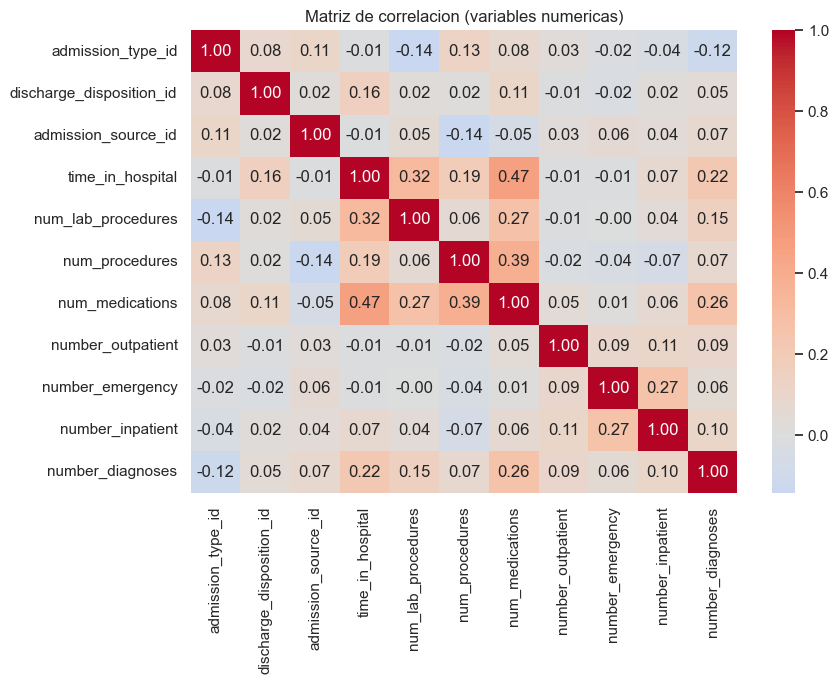

In [17]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlacion (variables numericas)")
plt.tight_layout()
plt.show()

> **Codigo: .** Calculamos la matriz de correlación de Pearson entre las 11 variables numéricas y la visualizamos como mapa de calor, con los valores anotados y una paleta divergente centrada en 0 (rojo = correlación positiva, azul = negativa).
>
> **Por qué.** Buscamos dos cosas: **redundancia** (variables que miden prácticamente lo mismo, lo que se llama multicolinealidad y perjudica a los modelos lineales) y **estructura** (grupos de variables que se mueven juntas y que quizá puedan resumirse en una sola). El mapa de calor permite leer 121 números de un vistazo.
>
> **Qué descubrimos.**
> - **No hay redundancia grave.** La correlación más alta entre dos variables distintas es **0.47**, muy lejos del 0.8-0.9 que obligaría a eliminar una de ellas. Podemos conservar todas las variables numéricas.
> - **Se distinguen dos bloques independientes entre sí:**
>   1. **Intensidad del episodio actual:** `num_medications` con `time_in_hospital` **0.47**, `num_medications` con `num_procedures` **0.39**, `time_in_hospital` con `num_lab_procedures` **0.32**, `num_medications` con `num_lab_procedures` **0.27**, `num_medications` con `number_diagnoses` **0.26** y `time_in_hospital` con `number_diagnoses` **0.22**. Todas positivas y moderadas, y tienen todo el sentido clínico: **estancias más largas implican más pruebas, más fármacos y más diagnósticos**. Este bloque podría resumirse en un único índice de gravedad o intensidad del ingreso.
>   2. **Historial previo del paciente:** `number_emergency` con `number_inpatient` **0.27** y `number_outpatient` con `number_inpatient` **0.11**. Es un grupo aparte, con correlaciones cercanas a 0 frente a todo el bloque anterior. Este es un hallazgo útil: **el historial previo aporta información completamente distinta de la del episodio actual**, así que ambos grupos merecen estar en el modelo.
> - Los valores de los tres `*_id` (por ejemplo `discharge_disposition_id` con `time_in_hospital`, 0.16) **no deben interpretarse**: son categorías codificadas y la correlación de Pearson sobre ellas no significa nada.
> - **Limitación metodológica importante:** Pearson mide solo relaciones **lineales** y asume variables continuas. Con conteos tan asimétricos como `number_outpatient` o `number_emergency` (casi todo ceros), **subestima la asociación real**. Para esas variables la **correlación de Spearman** (basada en rangos) sería más apropiada. Una correlación cercana a 0 no significa ausencia de relación, solo ausencia de relación *lineal*.
> - Recordemos además lo que acabamos de descubrir sobre `number_diagnoses`: como está truncada en 9, sus correlaciones (0.26 con `num_medications`, 0.22 con `time_in_hospital`) están **atenuadas** respecto a las reales.

## 8. Relacion de variables con el target

Se agrupa `readmitted` en dos clases (readmitido antes de 30 dias vs. el resto) para explorar mas facil
su relacion con otras variables. Esta seccion pone a prueba la hipotesis del equipo: que los pacientes
con mas hospitalizaciones previas (number_inpatient) tienen una tasa de readmision temprana mayor que
los que no las tienen. De paso miramos tambien number_emergency e insulin.


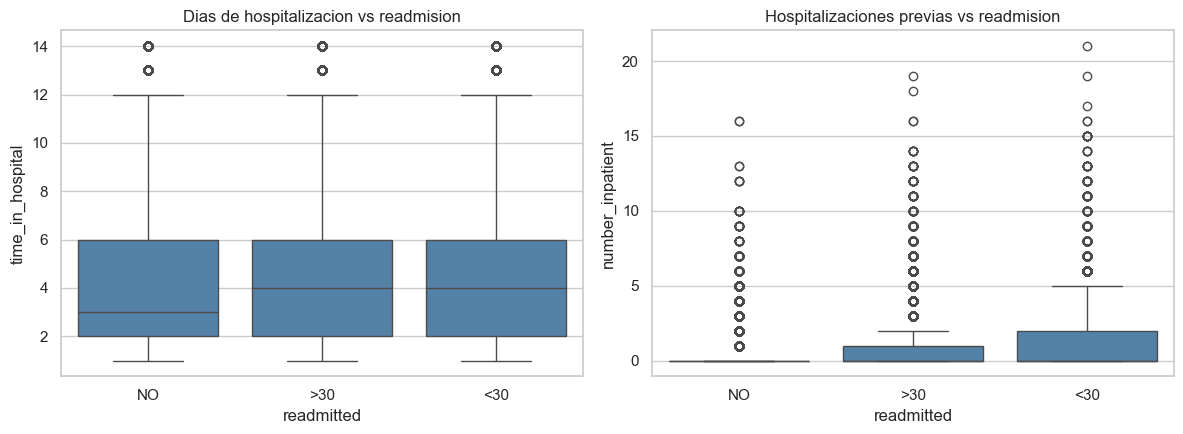

In [18]:
df["readmit_30"] = (df["readmitted"] == "<30")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="readmitted", y="time_in_hospital", order=["NO", ">30", "<30"], ax=axes[0], color="steelblue")
axes[0].set_title("Dias de hospitalizacion vs readmision")

sns.boxplot(data=df, x="readmitted", y="number_inpatient", order=["NO", ">30", "<30"], ax=axes[1], color="steelblue")
axes[1].set_title("Hospitalizaciones previas vs readmision")

plt.tight_layout()
plt.show()

> **Codigo: .** Creamos la variable binaria `readmit_30` (`True` si el reingreso fue en menos de 30 días) y comparamos con diagramas de caja cómo se distribuyen `time_in_hospital` y `number_inpatient` en cada clase del target.
>
> **Por qué.** Hasta ahora habíamos mirado cada variable por separado; este es el paso clave del EDA: **relacionar los predictores con el target**. Si la distribución de una variable cambia entre los grupos, esa variable tiene poder predictivo; si es igual en todos, no aporta. El diagrama de caja es ideal para esta comparación porque muestra a la vez mediana, dispersión y valores extremos. Y binarizar el target simplifica el problema a la pregunta que de verdad interesa: **¿volverá este paciente en menos de 30 días?**
>
> **Qué descubrimos.**
> - **`time_in_hospital` discrimina muy poco.** Las tres cajas son casi idénticas (rango intercuartílico de 2 a 6 días en todas) y las medianas apenas se mueven: **3 días en `NO` frente a 4 en `>30` y en `<30`**. Hay una tendencia en la dirección esperada, pero tan débil que **por sí sola esta variable es un predictor pobre**. Un hallazgo negativo también es un hallazgo: nos evita apostar por ella.
> - **`number_inpatient` sí discrimina, y con claridad.** Es el mejor predictor que hemos encontrado hasta ahora:
>   - En `NO` la caja entera está **colapsada en 0**: la gran mayoría de quienes no reingresan **no había estado hospitalizada el año anterior**.
>   - En `>30` la caja va de **0 a 1**.
>   - En `<30` la caja va de **0 a 2** y el bigote llega hasta 5.
>   - El patrón es inequívoco y además **monótono**: cuantas más hospitalizaciones previas, más probable y más temprano es el reingreso. Tiene mucho sentido clínico, porque refleja pacientes crónicos descompensados.
> - **Los puntos extremos no son errores.** En `number_inpatient` aparecen muchísimos puntos por encima del bigote (hasta **21 hospitalizaciones previas**), pero eso es consecuencia directa de la asimetría que ya vimos: cuando la mediana y el percentil 75 valen 0, la regla del diagrama de caja marca como extremo casi cualquier valor positivo. Son **pacientes crónicos reales, no ruido**, y precisamente los más relevantes para predecir reingresos: **eliminarlos sería un error grave**.

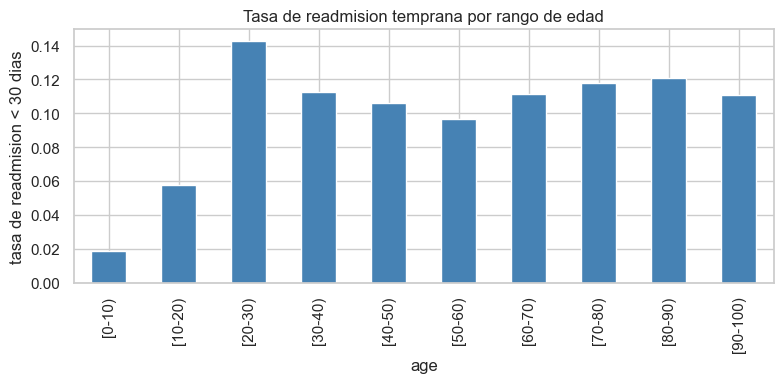

In [19]:
tasa_por_edad = df.groupby("age")["readmit_30"].mean().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
tasa_por_edad.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("tasa de readmision < 30 dias")
ax.set_title("Tasa de readmision temprana por rango de edad")
plt.tight_layout()
plt.show()

> **Codigo: .** Agrupamos por tramo de edad y calculamos la **media** de `readmit_30`. Como es una variable booleana, su media es directamente la **proporción de reingresos tempranos** de ese grupo. Ordenamos por índice para respetar el orden natural de la edad, no la frecuencia.
>
> **Por qué.** Es un cambio de pregunta importante respecto a la sección 6. Allí contamos **cuántos pacientes** hay en cada tramo de edad; aquí medimos **qué proporción de ellos reingresa**. Son cosas distintas: un grupo puede ser muy numeroso y reingresar poco, o muy pequeño y reingresar mucho. Para evaluar riesgo, lo que importa es la tasa. El truco de aplicar `mean()` a una columna booleana es un patrón muy útil en pandas.
>
> **Qué descubrimos.**
> - Como referencia, la tasa global es **11.2%**.
> - **Los tramos con volumen de datos son notablemente planos:** desde `[30-40)` hasta `[90-100)` todas las tasas caen entre **9.6% y 12.1%**. Se aprecia una leve tendencia creciente, con el mínimo en `[50-60)` (**9.6%**) y el máximo en `[80-90)` (**12.1%**), pero la diferencia es de apenas 2.5 puntos.
> - **Los extremos jóvenes son los que más se salen del patrón:** `[0-10)` tiene solo **1.8%**, `[10-20)` **5.7%**, y `[20-30)` es **la tasa más alta de todo el gráfico, 14.2%**.
> - **Pero hay que ser prudentes con esos extremos.** Son justamente los tramos con menos encuentros: en el gráfico de `age` de la sección 6 sus barras eran casi invisibles. Con pocos casos, un puñado de pacientes mueve mucho el porcentaje, así que **esas tasas son inestables y no conviene sobreinterpretarlas**. Lo correcto sería acompañar cada barra con su número de casos o con un intervalo de confianza. Es una lección importante del EDA: **una tasa sin su tamaño de muestra puede engañar**.
> - **Conclusión:** la edad aporta señal, pero **débil y no monótona**. No sirve como predictor principal, aunque sí puede ayudar combinada con otras variables. El contraste con `number_inpatient` de la celda anterior ilustra muy bien la diferencia entre una variable con señal fuerte y una con señal marginal.

number_emergency es, junto con number_inpatient, parte del bloque de "historial previo" que salio independiente en la correlacion (seccion 7). Vale la pena ver si tambien se mueve con la readmision.


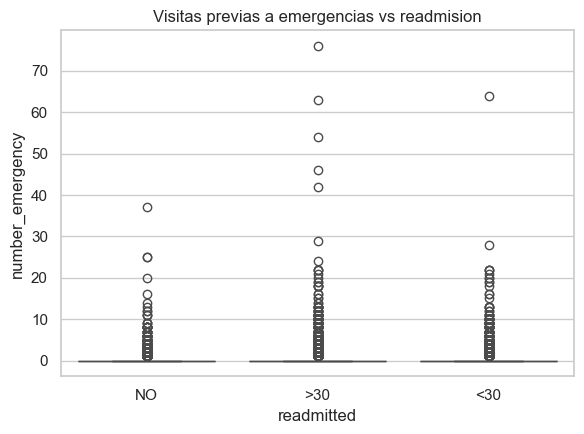

In [20]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x="readmitted", y="number_emergency", order=["NO", ">30", "<30"], ax=ax, color="steelblue")
ax.set_title("Visitas previas a emergencias vs readmision")
plt.tight_layout()
plt.show()


insulin es la unica columna de medicamentos que no esta casi toda concentrada en "No" (seccion 6). Aca comparamos la tasa de readmision temprana entre pacientes con ajuste de dosis (Up/Down), dosis estable (Steady) y sin insulina (No).


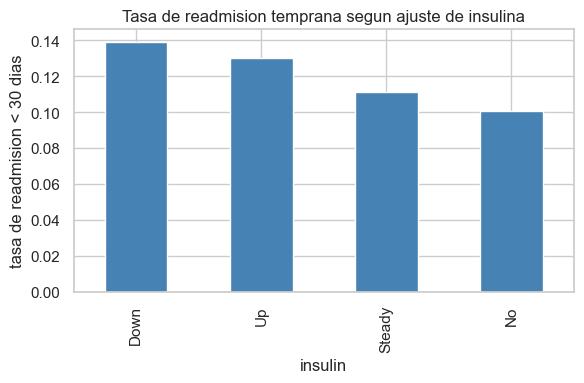

In [21]:
tasa_por_insulin = df.groupby("insulin")["readmit_30"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
tasa_por_insulin.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("tasa de readmision < 30 dias")
ax.set_title("Tasa de readmision temprana segun ajuste de insulina")
plt.tight_layout()
plt.show()


## 9. Conclusiones preliminares

### Estructura y calidad de los datos

- El dataset tiene **101,766 encuentros y 47 variables**, sin filas duplicadas. Pero la **unidad de analisis es el encuentro hospitalario, no el paciente**: los 101,766 encuentros pertenecen a solo **71,518 pacientes**, y el **46.2% de las filas** corresponde a pacientes que aparecen mas de una vez. **Casi la mitad de las filas no son observaciones independientes**, aunque ninguna este duplicada.
- **Decision tomada: conservamos todos los encuentros.** El encuentro es la unidad correcta para la pregunta real (Medicare penaliza por ingreso, y un modelo puntuaria cada admision), y reducir a un encuentro por paciente descartaria el 30% de los datos y toda la informacion de trayectoria. A cambio, el analisis asume tres cuidados obligatorios: **el split debe agrupar por `patient_nbr`** (`StratifiedGroupKFold`, nunca un `train_test_split` aleatorio, que dejaria el **41.5%** de las filas de test con un paciente ya visto en train), **los identificadores nunca son features**, y **toda cifra descriptiva debe declarar si es por encuentro o por paciente**.
- **La duplicacion desplaza las estadisticas y hay que tenerlo presente al leer todo lo que sigue:** quedandose con el primer encuentro de cada paciente, la tasa de readmision temprana baja del 11.16% al 8.80% y la media de `number_inpatient` cae de 0.64 a 0.18.
- **Los valores faltantes no son todos iguales y no se tratan igual.** `weight` (96.9%) se descarta sin mas. En cambio, el `NaN` de `max_glu_serum` (94.7%) y `A1Cresult` (83.3%) **significa "la prueba no se realizo"**: es informacion, no un dato perdido, y debe pasar a una categoria explicita `"No medido"`. Mismo criterio para `medical_specialty` (49.1%) y `payer_code` (39.6%) con `"Desconocido"`. `race` y los `diag_*` tienen tan pocos nulos que se pueden imputar o eliminar.
- **Hay columnas que no aportan absolutamente nada:** `examide` y `citoglipton` tienen un unico valor (varianza cero) y se deben eliminar; otras siete columnas de medicamentos tienen solo dos valores y son casi constantes.
- **Tres variables `int64` son en realidad categoricas:** `admission_type_id`, `discharge_disposition_id` y `admission_source_id`. Sus medias, sus histogramas y sus correlaciones no tienen interpretacion, y hay que recodificarlas antes de modelar.
- **`number_diagnoses` esta truncada en 9** por un limite del sistema de facturacion: el **48.6%** de los encuentros tiene exactamente 9 diagnosticos y solo **115 registros** superan ese valor. No es un conteo continuo real, asi que conviene agruparla (`1-5`, `6-8`, `9+`).
- **`diag_1`, `diag_2` y `diag_3` tienen 716, 748 y 789 categorias.** Hay que agruparlas por capitulo ICD-9 (a unos 9 grupos) antes de codificarlas. `medical_specialty`, con 72 categorias, tiene el mismo problema en menor escala.
- **Anomalia pendiente de investigar:** **5,641 encuentros** tienen 5 pruebas de laboratorio o menos, y de hecho la **moda de `num_lab_procedures` es 1** (3,208 encuentros), a pesar de que el criterio de inclusion del dataset exigia que se hubieran realizado pruebas de laboratorio.

### La variable objetivo

- El target esta **desbalanceado**: `NO` 53.9%, `>30` 34.9% y `<30` solo **11.2%**. La clase de mayor interes clinico y economico (readmision antes de 30 dias) es justamente la minoritaria, con un desbalance cercano a **8 a 1**.
- **Consecuencia directa y concreta:** predecir "sin readmision temprana" para todos los pacientes daria un **88.8% de acierto**, asi que **el accuracy no sirve como metrica en este problema**. Hay que evaluar con recall, precision, F1 o PR-AUC sobre la clase `<30`, y aplicar balanceo de clases (`class_weight`, submuestreo o SMOTE).

### Variables con mas y con menos senal

- **`number_inpatient` es el predictor mas prometedor** de todos los explorados: la caja esta colapsada en 0 para los no readmitidos, va de 0 a 1 en `>30` y de 0 a 2 en `<30`, con un patron monotono y clinicamente coherente. Sus valores extremos (hasta 21 ingresos previos) son pacientes cronicos reales y **no se deben eliminar**.
- **`time_in_hospital` discrimina poco** por si solo (mediana de 3 dias en `NO` frente a 4 en las clases readmitidas), y **la edad aporta una senal debil y no monotona**: entre `[30-40)` y `[90-100)` la tasa apenas se mueve (9.6% a 12.1%). Las tasas llamativas de los tramos jovenes (1.8% en `[0-10)`, 14.2% en `[20-30)`) se apoyan en muy pocos casos y son inestables.
- **De las 23 columnas de medicamentos, `insulin` es la unica realmente informativa:** la usa el **53.4%** de los encuentros y en el **23.1%** se ajusto la dosis durante la estancia. El resto esta entre el 88% y el 95% en `No`. En lugar de codificarlas todas, conviene construir variables agregadas (`n_farmacos_activos`, `hubo_ajuste_de_dosis`).
- **`change` (46.2% / 53.8%) y `diabetesMed` (77% / 23%) son las mejores candidatas categoricas:** completas, balanceadas y ya agregadas. Queda pendiente verificar su consistencia con una tabla cruzada (si `diabetesMed = No`, `change` deberia ser siempre `No`).
- **No hay multicolinealidad grave** (correlacion maxima 0.47) y se distinguen **dos bloques independientes entre si**: la intensidad del episodio actual (`time_in_hospital`, `num_medications`, `num_lab_procedures`, `num_procedures`, `number_diagnoses`) y el historial previo del paciente (`number_outpatient`, `number_emergency`, `number_inpatient`). Al ser independientes, **cada bloque aporta informacion distinta** y ambos merecen estar en el modelo.
- Los tres conteos de visitas previas son **extremadamente asimetricos** (mediana y percentil 75 en 0), asi que necesitan `log1p` o binarizacion. Para ellos **Spearman seria mas apropiado que Pearson**, que subestima su asociacion real.

### Limitaciones y alcance

- La poblacion es **mayoritariamente adulta mayor**: el **81.6%** de los encuentros esta entre los 50 y los 90 anos, con el pico en `[70-80)`. Las conclusiones **no se pueden extrapolar a pacientes jovenes**.
- `race` esta dominada por dos grupos (`Caucasian` 74.8% y `AfricanAmerican` 18.9%); `Hispanic`, `Other` y `Asian` juntas suman apenas el 4.1%. Cualquier resultado desagregado por raza sera poco fiable en esos grupos, y un modelo entrenado sobre estos datos tendera a funcionar peor precisamente ahi. `gender` incluye 3 registros `Unknown/Invalid` que conviene eliminar.
- Los datos son de **1999-2008 y de 130 hospitales de EE.UU.**, con un criterio de inclusion estricto (estancias de 1 a 14 dias, con pruebas de laboratorio y medicacion administrada). No representan la practica clinica actual ni otros sistemas de salud.


### La hipotesis, hasta donde alcanza el EDA

number_inpatient sigue siendo la variable con la relacion mas clara y monotona con la readmision temprana, y es la variable central de la hipotesis del equipo. De las otras dos predictoras del white paper, insulin tambien dio una senal util y ordenada: la tasa de readmision antes de 30 dias baja de forma escalonada segun el tipo de ajuste de dosis, mas alta con reduccion (Down, cerca de 13.9%), luego aumento (Up, cerca de 13.0%), despues dosis estable (Steady, cerca de 11.1%), y mas baja sin insulina (No, cerca de 10.0%). Un ajuste de dosis, sobre todo una reduccion, coincide con mas riesgo de reingreso temprano.

number_emergency, en cambio, no dejo ver nada claro con un boxplot: la variable esta tan concentrada en 0 (mediana 0 en las tres clases de readmitted) que la caja se aplasta y solo se distinguen los valores atipicos. Haria falta otra vista (por ejemplo, agrupar en tuvo visitas a emergencias si/no, como se hizo con la edad) para saber si de verdad aporta señal, algo que se puede resolver en la Parte II.

En conjunto, esto es solo el EDA, no una prueba: falta el modelado de la Parte II para confirmar cuales de estas variables siguen siendo relevantes una vez controladas por las demas.


# INICIO DE LA PARTE DOS DEL PROYECTO

## 10. Preparación de datos para modelado

In [22]:
#Se crea una copia del conjunto utilizado durante el EDA para realizar la preparación del modelado 
#sin modificar los datos originales. A partir de este punto, todas las transformaciones las realizamos sobre df_modelo.

df_modelo = df_id.copy()
print("Dimensiones iniciales:", df_modelo.shape)

Dimensiones iniciales: (101766, 50)


In [23]:
#Creamos la variable binaria derivada readmit_30

df_modelo["readmit_30"] = (
    df_modelo["readmitted"] == "<30"
).astype(int)
df_modelo["readmit_30"].value_counts()

readmit_30
0    90409
1    11357
Name: count, dtype: int64

In [24]:
# En nuestro EDA ya vimos que weight tiene 96.9% de faltantes y que examide y citoglipton tienen varianza cero. Así que procedemos a eliminarlas.
columnas_eliminar = [
    "weight",
    "examide",
    "citoglipton"
]

df_modelo = df_modelo.drop(columns=columnas_eliminar)
print("Dimensiones después de eliminar columnas:", df_modelo.shape)

Dimensiones después de eliminar columnas: (101766, 48)


In [25]:
# En el EDA se identifico que en max_glu_serum y A1Cresult el NaN tiene significado: la prueba no fue realizada. 
#Asi que hacemos explicita su categorización.

df_modelo["max_glu_serum"] = (df_modelo["max_glu_serum"].fillna("No medido"))
df_modelo["A1Cresult"] = (df_modelo["A1Cresult"].fillna("No medido"))
df_modelo["medical_specialty"] = (df_modelo["medical_specialty"].fillna("Desconocido"))
df_modelo["payer_code"] = (df_modelo["payer_code"].fillna("Desconocido"))

columnas_revisar = [
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

df_modelo[columnas_revisar].isna().sum()

max_glu_serum        0
A1Cresult            0
medical_specialty    0
payer_code           0
dtype: int64

In [26]:
# Eliminamos los generos invalidos y desconocidos
print(df_modelo["gender"].value_counts(dropna=False))

df_modelo = df_modelo[
    df_modelo["gender"] != "Unknown/Invalid"
].copy()

print("Filas restantes:", len(df_modelo))

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
Filas restantes: 101763


In [27]:
faltantes = (
    df_modelo.isna()
    .sum()
    .sort_values(ascending=False)
)

faltantes[faltantes > 0]

race      2271
diag_3    1423
diag_2     358
diag_1      21
dtype: int64

In [28]:
columnas_faltantes = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

df_modelo[columnas_faltantes] = (
    df_modelo[columnas_faltantes]
    .fillna("Desconocido")
)

print(
    "Faltantes restantes:",
    df_modelo.isna().sum().sum()
)

Faltantes restantes: 0


## 11. Ingeniería de características 

In [29]:
mapa_edad = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df_modelo["age_num"] = df_modelo["age"].map(mapa_edad)

df_modelo[["age", "age_num"]].drop_duplicates().sort_values("age_num")

,age,age_num
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45
5,[50-60),55
6,[60-70),65
7,[70-80),75
8,[80-90),85
9,[90-100),95


In [30]:
#Acá colocamos el punto medio de la edad y lo colocamos una nueva columna a la vez que eliminamos la anterior
df_modelo = df_modelo.drop(columns="age")  

In [31]:
columnas_medicamentos = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

columnas_medicamentos = [
    col for col in columnas_medicamentos
    if col in df_modelo.columns
]

df_modelo["n_farmacos_activos"] = (
    df_modelo[columnas_medicamentos]
    .ne("No")
    .sum(axis=1)
)

df_modelo["hubo_ajuste_de_dosis"] = (
    df_modelo[columnas_medicamentos]
    .isin(["Up", "Down"])
    .any(axis=1)
    .astype(int)
)

df_modelo["hubo_ajuste_de_dosis"].value_counts(normalize=True)

medicamentos_eliminar = [
    col for col in columnas_medicamentos
    if col != "insulin"
]

df_modelo = df_modelo.drop(
    columns=medicamentos_eliminar
)

In [32]:
X_modelo = df_modelo.drop(
    columns=[
        "readmitted",
        "readmit_30",
        "encounter_id",
        "patient_nbr"
    ]
)

y_modelo = df_modelo["readmit_30"].astype(int)

groups = df_modelo["patient_nbr"]

print("X:", X_modelo.shape)
print("y:", y_modelo.shape)
print("Pacientes:", groups.nunique())
print()
print("Distribución del target:")
print(y_modelo.value_counts(normalize=True))

X: (101763, 26)
y: (101763,)
Pacientes: 71515

Distribución del target:
readmit_30
0    0.888398
1    0.111602
Name: proportion, dtype: float64


## 12. Diseño de Evaluación

In [33]:
# Separamos los datos en entrenamiento y en prueba

from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(
        X_modelo,
        y_modelo,
        groups=groups
    )
)

X_train = X_modelo.iloc[train_idx].copy()
X_test = X_modelo.iloc[test_idx].copy()

y_train = y_modelo.iloc[train_idx].copy()
y_test = y_modelo.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

pacientes_compartidos = (set(groups_train) & set(groups_test))

print("Encuentros train:", len(X_train))
print("Encuentros test:", len(X_test))

print("Pacientes compartidos entre train y test:", len(pacientes_compartidos))
print("Tasa positiva train:", round(y_train.mean() * 100, 2), "%")
print("Tasa positiva test:", round(y_test.mean() * 100, 2), "%")

Encuentros train: 81410
Encuentros test: 20353
Pacientes compartidos entre train y test: 0
Tasa positiva train: 11.16 %
Tasa positiva test: 11.16 %


In [34]:
# Funcion para imprimir y comparar modelos

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluar_modelo(nombre, y_real, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1": f1_score(y_real, y_pred, zero_division=0)
    }

In [35]:
# Acá cambiamos tres variables que en primera instacia parecian numérica, pero son categóricas

columnas_id_categoricas = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

X_train[columnas_id_categoricas] = (X_train[columnas_id_categoricas].astype(str))
X_test[columnas_id_categoricas] = (X_test[columnas_id_categoricas].astype(str))

columnas_numericas = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

In [36]:
# Aquí aplicamos StandardScaler y OneHotEconder para que el modelo interprete correcatamente el tipo de variables.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            columnas_numericas
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            columnas_categoricas
        )
    ]
)

In [37]:
# Creación del baselina

from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

# Entrenamiento
modelo_logistico.fit(X_train, y_train)

# Predicción
y_pred_logistico = modelo_logistico.predict(X_test)

In [39]:
resultado_baseline = evaluar_modelo(
    "Baseline",
    y_test,
    y_pred_baseline
)

resultado_logistico = evaluar_modelo(
    "Regresión Logística",
    y_test,
    y_pred_logistico
)

In [40]:
#Impresión de los resultados y comparación de modelos

resultados_modelos = pd.DataFrame([
    resultado_baseline,
    resultado_logistico
])
resultados_modelos.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1": "{:.2%}"
})

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,88.84%,0.00%,0.00%,0.00%
1,Regresión Logística,66.03%,17.96%,57.26%,27.35%
